# EcoCool Potential Analysis: Step-by-Step Manual Execution (Emission Optimization)

This notebook allows you to run the EcoCool potential analysis step by step with **emission-based optimization**, with each step in a separate cell. This enables you to review and verify each intermediate result.

## How to Use

1. Run cells sequentially from top to bottom
2. Review outputs after each step
3. Modify parameters in configuration cells as needed
4. Skip optional steps (e.g., PV optimization) if not needed

## Prerequisites

- All dependencies installed (`pixi install`)
- Input data files available in `data/ecocool/`:
  - `power_data_ecocool_2024.csv` - Power consumption data
  - `emission_factor_2024.csv` - CO₂ emission factors (g CO₂/kWh or kg CO₂/kWh)
- `config.py` configured with system parameters (optional)


## Step 0: Setup and Imports

**What this step does:** Imports all necessary Python libraries (pandas, numpy, matplotlib) and sets display options for better data visualization.

**What you'll see:** Confirmation message that imports were successful.


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Imports successful!")


Imports successful!


## Step 0.1: Configuration

**What this step does:** Loads system parameters from `config.py` (if available) or sets default values for the EcoCool system. Defines temperature constraints, thermal properties, PCM parameters, data file paths, and analysis period.

**What you'll see:** Configuration summary showing system name, temperature settings, COP, and analysis period.


In [2]:
# Import configuration (optional - can override below)
try:
    from config import (
        COOLING_RAMP_SLOPE_IN_K_PER_H,
        WARMING_RAMP_SLOPE_IN_K_PER_H,
        COP,
        POWER_PRICE_IN_EURO_PER_KW,
    )
    print("Configuration loaded from config.py")
except ImportError as e:
    print(f"Warning: Could not import from config.py: {e}")
    print("Using default values...")
    # Set defaults for EcoCool
    COOLING_RAMP_SLOPE_IN_K_PER_H = -1.0
    WARMING_RAMP_SLOPE_IN_K_PER_H = 2.0
    COP = 2.5
    POWER_PRICE_IN_EURO_PER_KW = 100

# EcoCool system parameters
SYSTEM_NAME = "EcoCool"
DEFAULT_INDOOR_TEMP = -20.0  # °C (typical for deep freeze)
MIN_TEMP_ALLOWED = -25.0  # °C
MAX_TEMP_ALLOWED = -15.0  # °C

# Thermal properties (to be calibrated)
WALL_AREA = 100.0  # m² (total wall area)
INSULATION_THICKNESS = 0.15  # m
INSULATION_TYPE = "polyurethane"  # Typical for cold storage
CONTENT_MASS = 5000.0  # kg (air + contents)
SPECIFIC_HEAT_CAPACITY = 1005.0  # J/(kg·K) (air)

# PCM parameters (currently no PCM)
PCM_MASS = 0.0  # kg
LATENT_HEAT_CAPACITY = 200000.0  # J/kg (not used if PCM_MASS = 0)
PHASE_CHANGE_TEMP = -20.0  # °C (not used if PCM_MASS = 0)
LATENT_HEAT_FACTOR = 1.0  # No PCM benefit

# Data file paths - MODIFY THESE TO MATCH YOUR SYSTEM
PROJECT_ROOT = Path.cwd()
ECOCOOL_DATA_DIR = PROJECT_ROOT / "data" / "ecocool"
power_data_path = ECOCOOL_DATA_DIR / "power_data_ecocool_2024.csv"
emission_factor_path = ECOCOOL_DATA_DIR / "emission_factor_2024.csv"

# Analysis period
start_date = pd.Timestamp('2024-05-01 00:00:00')
end_date = pd.Timestamp('2024-05-02 23:45:00')

# Report directory
report_directory = "reports/ecocool/manual_analysis"
os.makedirs(report_directory, exist_ok=True)

print(f"\nConfiguration:")
print(f"  System: {SYSTEM_NAME}")
print(f"  Default temp: {DEFAULT_INDOOR_TEMP}°C")
print(f"  Temp range: {MIN_TEMP_ALLOWED}°C to {MAX_TEMP_ALLOWED}°C")
print(f"  COP: {COP}")
print(f"  Analysis period: {start_date} to {end_date}")


Configuration loaded from config.py

Configuration:
  System: EcoCool
  Default temp: -20.0°C
  Temp range: -25.0°C to -15.0°C
  COP: 2.8
  Analysis period: 2024-05-01 00:00:00 to 2024-05-02 23:45:00


## Step 1: Load Power Consumption Data

**What this step does:** Loads the power consumption data from the CSV file. This is the baseline (measured) power consumption of the EcoCool cooling system.

**What you'll see:** Number of rows loaded, column names, and first few rows of raw data showing hourly power measurements.


In [3]:
# Load power data
print(f"Loading power data from: {power_data_path}")
if not power_data_path.exists():
    raise FileNotFoundError(f"Power data file not found: {power_data_path}")

df_power = pd.read_csv(power_data_path)
print(f"\nLoaded {len(df_power)} rows")
print(f"Columns: {df_power.columns.tolist()}")
print(f"\nFirst few rows:")
print(df_power.head(30))


Loading power data from: C:\Users\MichaelDotan\phase_change_cooling_analysis\data\ecocool\power_data_ecocool_2024.csv

Loaded 8526 rows
Columns: ['interval', 'ElectricMeter_Kaelteanlage_power', 'ElectricMeter_Zaehler_Gesamt_power']

First few rows:
                     interval  ElectricMeter_Kaelteanlage_power  \
0   2024-01-01 00:00:00+00:00                         25.559423   
1   2024-01-01 01:00:00+00:00                         29.535904   
2   2024-01-01 02:00:00+00:00                         27.674923   
3   2024-01-01 03:00:00+00:00                         32.451653   
4   2024-01-01 04:00:00+00:00                         51.723980   
5   2024-01-01 05:00:00+00:00                         19.714693   
6   2024-01-01 06:00:00+00:00                         20.348461   
7   2024-01-01 07:00:00+00:00                         26.736326   
8   2024-01-01 08:00:00+00:00                         30.727770   
9   2024-01-01 09:00:00+00:00                         54.857230   
10  2024-01-01

## Step 1.1: Process Power Data Timestamps

**What this step does:** Converts timestamp columns to datetime index, filters data for the analysis period, and resamples to 15-minute intervals. Identifies the power column and renames it to `Standortverbrauch` (site consumption).

**What you'll see:** Processed data shape, time range, power range, and first few rows with proper datetime index. Note: Hourly data will show NaN values at 15-minute intervals until forward-filled in Step 3.


In [4]:
# Find timestamp column
timestamp_col = None
for col in ['interval', 'timestamp', 'Timestamp', 'time', 'Time', 'datetime', 'DateTime']:
    if col in df_power.columns:
        timestamp_col = col
        break

if timestamp_col is None:
    # Create timestamp index if not present
    print("No timestamp column found, creating sequential timestamps")
    df_power.index = pd.date_range(
        start='2024-01-01 00:00:00',
        periods=len(df_power),
        freq='15min'
    )
    df_power.index.name = 'timestamp'
else:
    df_power[timestamp_col] = pd.to_datetime(df_power[timestamp_col])
    df_power = df_power.set_index(timestamp_col, drop=True)

# Find power column
power_col = None
for col in ['ElectricMeter_Kaelteanlage_power', 'processPowerEl', 'power', 'Power', 'consumption', 'Consumption']:
    if col in df_power.columns:
        power_col = col
        break

if power_col is None:
    raise ValueError(f"Could not find power column. Available columns: {df_power.columns.tolist()}")

# Remove timezone if present
if df_power.index.tz is not None:
    df_power.index = df_power.index.tz_localize(None)

# Filter for analysis period
df_power = df_power[(df_power.index >= start_date) & (df_power.index <= end_date)]

# Resample to 15-minute intervals if needed
if df_power.index.freq is None or df_power.index.freq != pd.Timedelta('15min'):
    print(f"Resampling to 15-minute intervals")
    df_power = df_power.resample('15min').mean()

# Rename power column to standard name
df_power['Standortverbrauch'] = df_power[power_col]

print(f"\nAfter processing:")
print(f"  Shape: {df_power.shape}")
print(f"  Time range: {df_power.index.min()} to {df_power.index.max()}")
print(f"  Power range: {df_power['Standortverbrauch'].min():.2f} to {df_power['Standortverbrauch'].max():.2f} kW")
print(f"\nFirst few rows:")
print(df_power[['Standortverbrauch']].head(30))


Resampling to 15-minute intervals

After processing:
  Shape: (189, 3)
  Time range: 2024-05-01 00:00:00 to 2024-05-02 23:00:00
  Power range: 3.29 to 73.09 kW

First few rows:
                     Standortverbrauch
interval                              
2024-05-01 00:00:00          18.892500
2024-05-01 00:15:00                NaN
2024-05-01 00:30:00                NaN
2024-05-01 00:45:00                NaN
2024-05-01 01:00:00          17.321712
2024-05-01 01:15:00                NaN
2024-05-01 01:30:00                NaN
2024-05-01 01:45:00                NaN
2024-05-01 02:00:00          41.540867
2024-05-01 02:15:00                NaN
2024-05-01 02:30:00                NaN
2024-05-01 02:45:00                NaN
2024-05-01 03:00:00          22.683884
2024-05-01 03:15:00                NaN
2024-05-01 03:30:00                NaN
2024-05-01 03:45:00                NaN
2024-05-01 04:00:00          21.995634
2024-05-01 04:15:00                NaN
2024-05-01 04:30:00                NaN
2024

## Step 2: Load Emission Factor Data

**What this step does:** Loads CO₂ emission factors from the CSV file. These factors indicate how "clean" or "dirty" the electricity grid is at each time (g CO₂/kWh).

**Understanding emission factors:**
- **Low values (clean grid):** Low CO₂ emissions per kWh - typically when renewable energy (solar, wind, hydro) is abundant
- **High values (dirty grid):** High CO₂ emissions per kWh - typically when fossil fuels (coal, natural gas) are used more

**What you'll see:** Number of rows loaded, column names, and first few rows showing emission factors over time. Higher values = dirtier grid, lower values = cleaner grid.


In [15]:
# Load emission factors
print(f"Loading emission factors from: {emission_factor_path}")
if not emission_factor_path.exists():
    raise FileNotFoundError(f"Emission factor file not found: {emission_factor_path}")

df_emission = pd.read_csv(emission_factor_path)
print(f"\nLoaded {len(df_emission)} rows")
print(f"Columns: {df_emission.columns.tolist()}")
print(f"\nFirst few rows:")
print(df_emission.head(30))


Loading emission factors from: C:\Users\MichaelDotan\phase_change_cooling_analysis\data\ecocool\emission_factor_2024.csv

Loaded 8764 rows
Columns: ['dateTime', 'dateTime.1', 'consumption_co2_intensity']

First few rows:
                     dateTime                 dateTime.1  \
0   2023-12-31 23:00:00+00:00  2023-12-31 23:00:00+00:00   
1   2024-01-01 00:00:00+00:00  2024-01-01 00:00:00+00:00   
2   2024-01-01 01:00:00+00:00  2024-01-01 01:00:00+00:00   
3   2024-01-01 02:00:00+00:00  2024-01-01 02:00:00+00:00   
4   2024-01-01 03:00:00+00:00  2024-01-01 03:00:00+00:00   
5   2024-01-01 04:00:00+00:00  2024-01-01 04:00:00+00:00   
6   2024-01-01 05:00:00+00:00  2024-01-01 05:00:00+00:00   
7   2024-01-01 06:00:00+00:00  2024-01-01 06:00:00+00:00   
8   2024-01-01 07:00:00+00:00  2024-01-01 07:00:00+00:00   
9   2024-01-01 08:00:00+00:00  2024-01-01 08:00:00+00:00   
10  2024-01-01 09:00:00+00:00  2024-01-01 09:00:00+00:00   
11  2024-01-01 10:00:00+00:00  2024-01-01 10:00:00+00:00   

## Step 2.1: Process Emission Factor Data

**What this step does:** Converts timestamp columns to datetime index, detects and converts units (kg to g CO₂/kWh if needed), resamples to 15-minute intervals, and removes duplicate datetime columns.

**What you'll see:** Emission factor range (min/max), time range, and first few rows. The emission factors will be used to optimize when to cool more (low emissions = clean grid) vs. less (high emissions = dirty grid).


In [16]:
# Find timestamp column in emission data
emission_timestamp_col = None
for col in ['dateTime', 'dateTime.1', 'timestamp', 'Timestamp', 'time', 'Time', 'datetime', 'DateTime']:
    if col in df_emission.columns:
        emission_timestamp_col = col
        break

if emission_timestamp_col:
    df_emission[emission_timestamp_col] = pd.to_datetime(df_emission[emission_timestamp_col])
    df_emission = df_emission.set_index(emission_timestamp_col, drop=True)
    # Drop any other datetime columns (e.g., dateTime.1 if dateTime was used as index)
    datetime_cols_to_drop = [col for col in df_emission.columns if col in ['dateTime', 'dateTime.1', 'timestamp', 'Timestamp', 'time', 'Time', 'datetime', 'DateTime']]
    if datetime_cols_to_drop:
        df_emission = df_emission.drop(columns=datetime_cols_to_drop)

# Find emission factor column
emission_col = None
for col in ['consumption_co2_intensity', 'emission_factor', 'emissionFactor', 'emission', 'Emission', 'co2', 'CO2']:
    if col in df_emission.columns:
        emission_col = col
        break

if emission_col is None:
    raise ValueError(f"Could not find emission factor column. Available columns: {df_emission.columns.tolist()}")

# Remove timezone if present
if df_emission.index.tz is not None:
    df_emission.index = df_emission.index.tz_localize(None)

# Check if emission factors are in g CO₂/kWh or kg CO₂/kWh
# Convert to g CO₂/kWh if needed (assume > 100 means it's in g, < 1 means it's in kg)
if df_emission[emission_col].max() < 1.0:
    print(f"Converting emission factors from kg CO₂/kWh to g CO₂/kWh")
    df_emission[emission_col] = df_emission[emission_col] * 1000.0
elif df_emission[emission_col].max() > 1000.0:
    print(f"Emission factors appear to be in g CO₂/kWh (max: {df_emission[emission_col].max():.1f} g/kWh)")

# Resample to 15-minute intervals
df_emission_resampled = df_emission[[emission_col]].resample('15min').mean()

print(f"\nAfter processing:")
print(f"  Emission factor range: {df_emission_resampled[emission_col].min():.1f} to {df_emission_resampled[emission_col].max():.1f} g CO₂/kWh")
print(f"  Time range: {df_emission_resampled.index.min()} to {df_emission_resampled.index.max()}")
print(f"\nFirst few rows:")
print(df_emission_resampled.head(30))



After processing:
  Emission factor range: 66.0 to 542.5 g CO₂/kWh
  Time range: 2023-12-31 23:00:00 to 2024-12-31 23:00:00

First few rows:
                     consumption_co2_intensity
dateTime                                      
2023-12-31 23:00:00                   126.7692
2023-12-31 23:15:00                        NaN
2023-12-31 23:30:00                        NaN
2023-12-31 23:45:00                        NaN
2024-01-01 00:00:00                   130.7555
2024-01-01 00:15:00                        NaN
2024-01-01 00:30:00                        NaN
2024-01-01 00:45:00                        NaN
2024-01-01 01:00:00                   131.3734
2024-01-01 01:15:00                        NaN
2024-01-01 01:30:00                        NaN
2024-01-01 01:45:00                        NaN
2024-01-01 02:00:00                   135.2470
2024-01-01 02:15:00                        NaN
2024-01-01 02:30:00                        NaN
2024-01-01 02:45:00                        NaN
2024-01-01 0

## Step 3: Merge All Input Data

**What this step does:** Combines power consumption and emission factor data into a single dataframe. Forward-fills hourly data to fill 15-minute intervals (carries each hour's value forward to 00:15, 00:30, 00:45).

**What you'll see:** Combined data shape, column list, missing values count (should be 0 after forward-fill), and first few rows showing both power and emission factors aligned in time.


In [19]:
# Merge all data
df = df_power.copy()
df = df.join(df_emission_resampled, how='left')

# Ensure no missing values in critical columns
# Forward-fill power data (hourly data) to fill 15-minute intervals
# This carries the last known power value forward until the next hour's value is available
df['Standortverbrauch'] = df['Standortverbrauch'].ffill().bfill()

# Forward-fill emission factors (hourly data) to fill 15-minute intervals
# This carries the last known emission factor forward until the next hour's value is available
df[emission_col] = df[emission_col].ffill().bfill()

# Rename emission column to standard name
df['Emission Factor (g CO2/kWh)'] = df[emission_col]

print(f"\nCombined data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMissing values per column:")
print(df.isna().sum())
print(f"\nFirst few rows:")
print(df[['Standortverbrauch', 'Emission Factor (g CO2/kWh)']].head(30))



Combined data shape: (189, 5)
Columns: ['ElectricMeter_Kaelteanlage_power', 'ElectricMeter_Zaehler_Gesamt_power', 'Standortverbrauch', 'consumption_co2_intensity', 'Emission Factor (g CO2/kWh)']

Missing values per column:
ElectricMeter_Kaelteanlage_power      141
ElectricMeter_Zaehler_Gesamt_power    141
Standortverbrauch                       0
consumption_co2_intensity               0
Emission Factor (g CO2/kWh)             0
dtype: int64

First few rows:
                     Standortverbrauch  Emission Factor (g CO2/kWh)
interval                                                           
2024-05-01 00:00:00          18.892500                     204.1990
2024-05-01 00:15:00          18.892500                     204.1990
2024-05-01 00:30:00          18.892500                     204.1990
2024-05-01 00:45:00          18.892500                     204.1990
2024-05-01 01:00:00          17.321712                     201.9071
2024-05-01 01:15:00          17.321712                     2

## Step 4: Configure Cooling System Properties

**What this step does:** Calculates thermal properties of the cooling system:
- **U-value**: Heat transfer coefficient through walls (W/(m²·K))
- **Overall U**: Total heat transfer coefficient (U × Area) in W/K
- **Heat capacity**: Thermal mass of air and contents (MJ/K)

These properties determine how much power is needed to maintain or change temperatures.

**What you'll see:** Calculated U-value, overall heat transfer coefficient, heat capacity, and stored properties dictionaries.


In [20]:
from utils.insulation_calculator import calculate_heat_transfer_coefficient

# Calculate U-value
u_value = calculate_heat_transfer_coefficient(
    insulation_thickness_m=INSULATION_THICKNESS,
    insulation_type=INSULATION_TYPE
)
print(f"Calculated U-value: {u_value:.4f} W/(m²·K)")

# Calculate overall heat transfer coefficient (U × Area)
overall_u = u_value * WALL_AREA
print(f"Overall U: {overall_u:.2f} W/K")

# Calculate heat capacity
overall_heat_capacity = CONTENT_MASS * SPECIFIC_HEAT_CAPACITY
print(f"Heat capacity: {overall_heat_capacity/1e6:.2f} MJ/K")

# Store properties
mapping_of_walls_properties = {
    SYSTEM_NAME: {
        "area": WALL_AREA,
        "heat_transfer_coef": u_value,
    }
}

mapping_of_content_properties = {
    SYSTEM_NAME: {
        "mass": CONTENT_MASS,
        "specific_heat_capacity": SPECIFIC_HEAT_CAPACITY,
    }
}

print(f"\nWall properties: {mapping_of_walls_properties}")
print(f"Content properties: {mapping_of_content_properties}")


Calculated U-value: 3.3333 W/(m²·K)
Overall U: 333.33 W/K
Heat capacity: 5.03 MJ/K

Wall properties: {'EcoCool': {'area': 100.0, 'heat_transfer_coef': 3.3333333333333335}}
Content properties: {'EcoCool': {'mass': 5000.0, 'specific_heat_capacity': 1005.0}}


## Step 5: Create Temperature Schedule (Emission-Based)

**What this step does:** Creates an optimized temperature schedule based on emission factors:
- **Low emissions (clean grid)** → Lower temperature (more cooling when grid is clean)
  - Clean grid = Low CO₂ emissions (g CO₂/kWh) - happens when renewable energy (solar, wind, hydro) is abundant
- **High emissions (dirty grid)** → Higher temperature (less cooling when grid is dirty)
  - Dirty grid = High CO₂ emissions (g CO₂/kWh) - happens when fossil fuels (coal, gas) are used more

**Strategy:** Cool more when electricity is clean (low emissions) to "store" cooling, then use less cooling when electricity is dirty (high emissions). This minimizes total CO₂ emissions.

The schedule respects ramp rate constraints (max temperature change rate) and stays within allowed temperature bounds.

**What you'll see:** Temperature schedule range and mean, first few rows showing schedule vs. emission factors, and a visualization plot showing emission factors over time and the resulting temperature schedule.



Temperature schedule created:
  Range: -24.79 to -15.00 °C
  Mean: -20.54 °C

First few rows:
                     EcoCool_Temperature Schedule  Emission Factor (g CO2/kWh)
interval                                                                      
2024-05-01 00:00:00                    -15.000000                     204.1990
2024-05-01 00:15:00                    -15.000000                     204.1990
2024-05-01 00:30:00                    -15.000000                     204.1990
2024-05-01 00:45:00                    -15.000000                     204.1990
2024-05-01 01:00:00                    -15.181179                     201.9071
2024-05-01 01:15:00                    -15.181179                     201.9071
2024-05-01 01:30:00                    -15.181179                     201.9071
2024-05-01 01:45:00                    -15.181179                     201.9071
2024-05-01 02:00:00                    -15.431179                     190.5397
2024-05-01 02:15:00                 

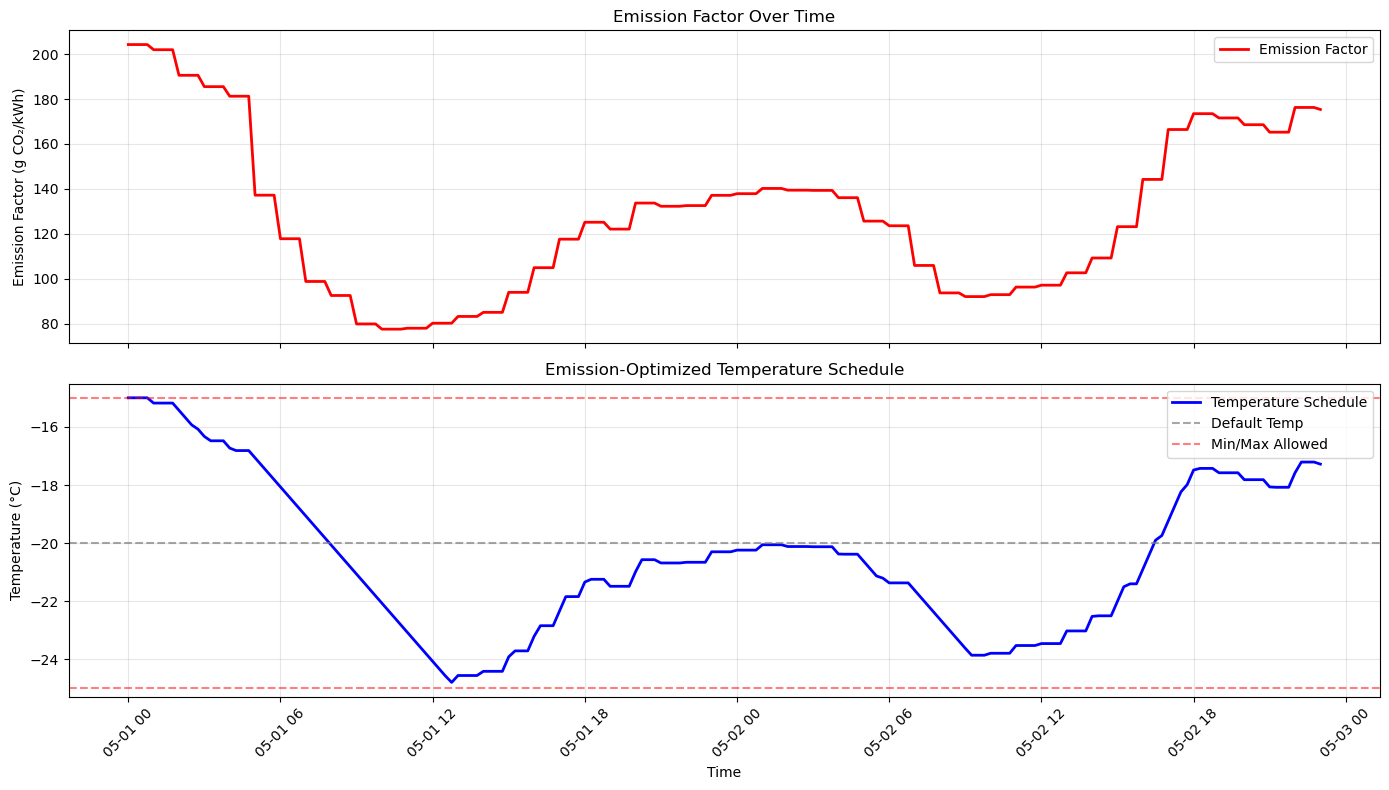

In [21]:
from analysis.emission_schedule_creators import create_emission_like_schedule

# Add temperature constraints to dataframe
df[f'{SYSTEM_NAME}_Default Indoor Temp'] = DEFAULT_INDOOR_TEMP
df[f'{SYSTEM_NAME}_Min Temp Allowed'] = MIN_TEMP_ALLOWED
df[f'{SYSTEM_NAME}_Max Temp Allowed'] = MAX_TEMP_ALLOWED

# Create emission-based temperature schedule
# Lower temperatures when emissions are low (grid is clean), higher when emissions are high (grid is dirty)
df[f'{SYSTEM_NAME}_Temperature Schedule'] = create_emission_like_schedule(
    df=df,
    emission_factor_col='Emission Factor (g CO2/kWh)',
    min_temp_allowed_col=f'{SYSTEM_NAME}_Min Temp Allowed',
    max_temp_allowed_col=f'{SYSTEM_NAME}_Max Temp Allowed',
    ramp_slope_in_k_per_h=abs(COOLING_RAMP_SLOPE_IN_K_PER_H),
    phase_change_temp=PHASE_CHANGE_TEMP if PCM_MASS > 0 else None,
)

print(f"\nTemperature schedule created:")
print(f"  Range: {df[f'{SYSTEM_NAME}_Temperature Schedule'].min():.2f} to {df[f'{SYSTEM_NAME}_Temperature Schedule'].max():.2f} °C")
print(f"  Mean: {df[f'{SYSTEM_NAME}_Temperature Schedule'].mean():.2f} °C")
print(f"\nFirst few rows:")
print(df[[f'{SYSTEM_NAME}_Temperature Schedule', 'Emission Factor (g CO2/kWh)']].head(30))

# Visualize schedule
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df.index, df['Emission Factor (g CO2/kWh)'], label='Emission Factor', color='red', linewidth=2)
axes[0].set_ylabel('Emission Factor (g CO₂/kWh)')
axes[0].set_title('Emission Factor Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df.index, df[f'{SYSTEM_NAME}_Temperature Schedule'], label='Temperature Schedule', color='blue', linewidth=2)
axes[1].axhline(y=DEFAULT_INDOOR_TEMP, color='gray', linestyle='--', label='Default Temp', alpha=0.7)
axes[1].axhline(y=MIN_TEMP_ALLOWED, color='red', linestyle='--', label='Min/Max Allowed', alpha=0.5)
axes[1].axhline(y=MAX_TEMP_ALLOWED, color='red', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_xlabel('Time')
axes[1].set_title('Emission-Optimized Temperature Schedule')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Step 6: Calculate Cooling Power (Temperature → Electrical Load)

**What this step does:** Calculates the electrical power consumption required to follow the optimized temperature schedule. This accounts for:
1. **Baseline cooling** (original power consumption)
2. **Additional cooling** needed when temperature is below default (more cooling)
3. **Reduced cooling** when temperature is above default (less cooling)
4. **Temperature change rate** (power needed to change temperature)
5. **System efficiency** (COP - Coefficient of Performance)

**What you'll see:** Power range, mean, and total energy for both baseline and optimized scenarios, plus a comparison plot showing both power curves.


### Understanding the Power Curves

The plot above shows two power curves:

**1. Baseline Power (Blue line - `Standortverbrauch`):**
- **Source:** Measured power consumption from actual EcoCool system operation
- **Temperature:** Constant at default temperature (-20°C)
- **Strategy:** No optimization - follows actual usage patterns
- **Represents:** Real-world power consumption before optimization

**2. Optimized Power (Orange line - `EcoCool_Cooling Power After Optimization`):**
- **Source:** Calculated power consumption based on emission-optimized temperature schedule
- **Temperature:** Varies based on emission factors (lower when grid is clean, higher when dirty)
- **Strategy:** Emission-minimizing - shifts consumption to low-emission times
- **Represents:** Simulated power consumption if system follows the optimized schedule

**How the optimized power is calculated:**
```
Optimized Power = Baseline Power + Additional Cooling Load / (COP × latent_heat_factor)
```

Where additional cooling load accounts for:
- **Temperature deviation:** More cooling needed when schedule temp < default temp
- **Temperature change rate:** Power needed to change temperature (cooling down or warming up)
- **PCM benefits:** Reduced cooling needed when operating near phase change temperature (if PCM present)

**Key insight:** The optimized curve shifts power consumption to times when grid emissions are low, reducing total CO₂ emissions even if total energy consumption is similar.



Cooling power after optimization:
  Range: 3.63 to 74.02 kW
  Mean: 29.32 kW
  Total energy: 1385.23 kWh

Baseline (before optimization):
  Mean: 29.14 kW
  Total energy: 1377.04 kWh


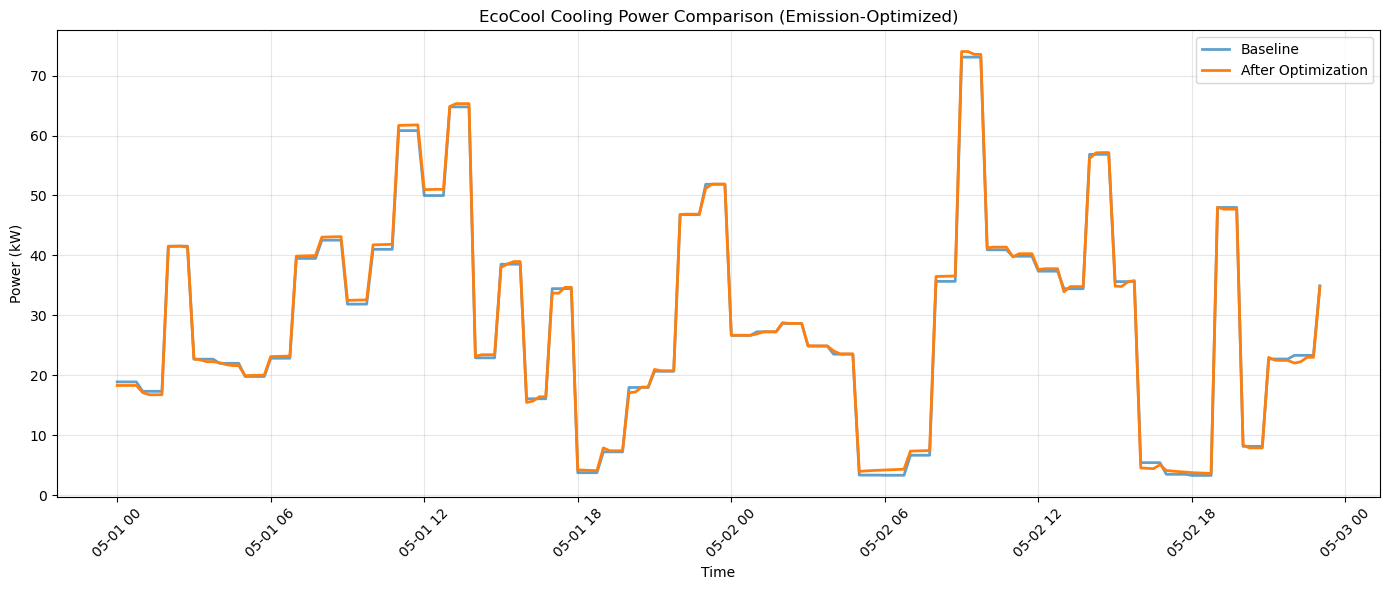

In [27]:
from analysis.phase_change_models import calculate_phase_change_cooling_power

# Calculate cooling power based on temperature schedule
df[f'{SYSTEM_NAME}_Cooling Power After Optimization'] = calculate_phase_change_cooling_power(
    df=df,
    cooling_power_col='Standortverbrauch',  # Baseline cooling
    schedule_temp_col=f'{SYSTEM_NAME}_Temperature Schedule',
    dflt_indoor_temp_col=f'{SYSTEM_NAME}_Default Indoor Temp',
    overall_heat_transfer_coef_in_w_per_k=overall_u,
    overall_heat_capacity_in_j_per_k=overall_heat_capacity,
    latent_heat_capacity_in_j_per_kg=LATENT_HEAT_CAPACITY,
    pcm_mass_in_kg=PCM_MASS,
    phase_change_temp_in_c=PHASE_CHANGE_TEMP,
    cop=COP,
    latent_heat_factor=LATENT_HEAT_FACTOR,
)

col = f'{SYSTEM_NAME}_Cooling Power After Optimization'
print(f"\nCooling power after optimization:")
print(f"  Range: {df[col].min():.2f} to {df[col].max():.2f} kW")
print(f"  Mean: {df[col].mean():.2f} kW")
print(f"  Total energy: {df[col].sum() * 0.25:.2f} kWh")
print(f"\nBaseline (before optimization):")
print(f"  Mean: {df['Standortverbrauch'].mean():.2f} kW")
print(f"  Total energy: {df['Standortverbrauch'].sum() * 0.25:.2f} kWh")

# Visualize comparison
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Standortverbrauch'], label='Baseline', linewidth=2, alpha=0.7)
plt.plot(df.index, df[col], label='After Optimization', linewidth=2)
plt.ylabel('Power (kW)')
plt.xlabel('Time')
plt.title(f'{SYSTEM_NAME} Cooling Power Comparison (Emission-Optimized)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Step 7: Calculate Grid Power After Optimization

**What this step does:** Calculates grid power consumption before and after optimization. Grid power represents the actual power drawn from the electrical grid (excluding any PV self-consumption if present).

**What you'll see:** Mean grid power before and after optimization, and a comparison plot showing how grid power consumption changes with the optimized schedule.



Grid Power:
  Before (mean): 29.14 kW
  After (mean): 29.32 kW


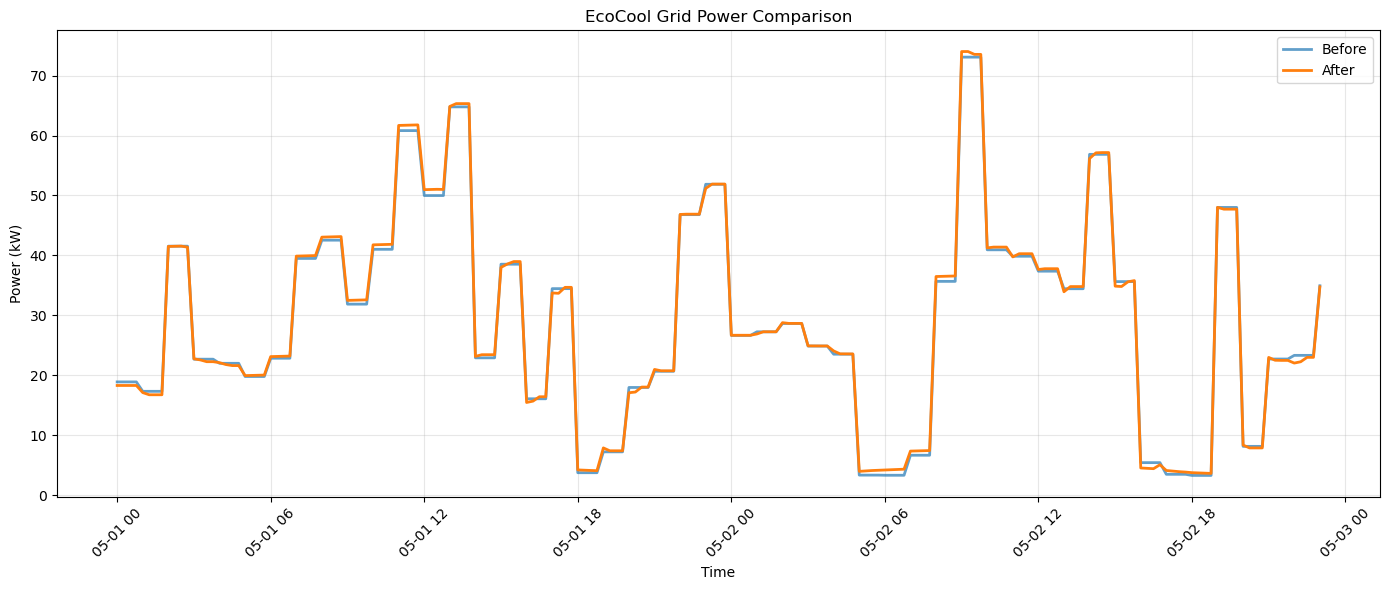

In [23]:
# Calculate grid power before (baseline)
df[f'{SYSTEM_NAME}_Grid Power Before'] = df['Standortverbrauch']

# Calculate grid power after optimization
df[f'{SYSTEM_NAME}_Grid Power After'] = df[f'{SYSTEM_NAME}_Cooling Power After Optimization']

print(f"\nGrid Power:")
print(f"  Before (mean): {df[f'{SYSTEM_NAME}_Grid Power Before'].mean():.2f} kW")
print(f"  After (mean): {df[f'{SYSTEM_NAME}_Grid Power After'].mean():.2f} kW")

# Visualize comparison
plt.figure(figsize=(14, 6))
plt.plot(df.index, df[f'{SYSTEM_NAME}_Grid Power Before'], label='Before', linewidth=2, alpha=0.7)
plt.plot(df.index, df[f'{SYSTEM_NAME}_Grid Power After'], label='After', linewidth=2)
plt.ylabel('Power (kW)')
plt.xlabel('Time')
plt.title(f'{SYSTEM_NAME} Grid Power Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Step 8: Calculate Emissions and Savings

**What this step does:** Calculates CO₂ emissions for both baseline and optimized scenarios by multiplying energy consumption by emission factors. Computes total emissions, emission savings (in kg CO₂), and savings percentage.

**What you'll see:** 
- Total emissions before and after optimization
- Emission savings in kg CO₂ and percentage
- Two plots: hourly emissions comparison and cumulative emissions over time

**Key metric:** Emission savings shows how much CO₂ can be reduced by following the optimized schedule.



Emission Analysis:
  Total emissions before: 17486.07 kg CO₂
  Total emissions after: 17596.18 kg CO₂
  Emission savings: -110.11 kg CO₂ (-0.6%)


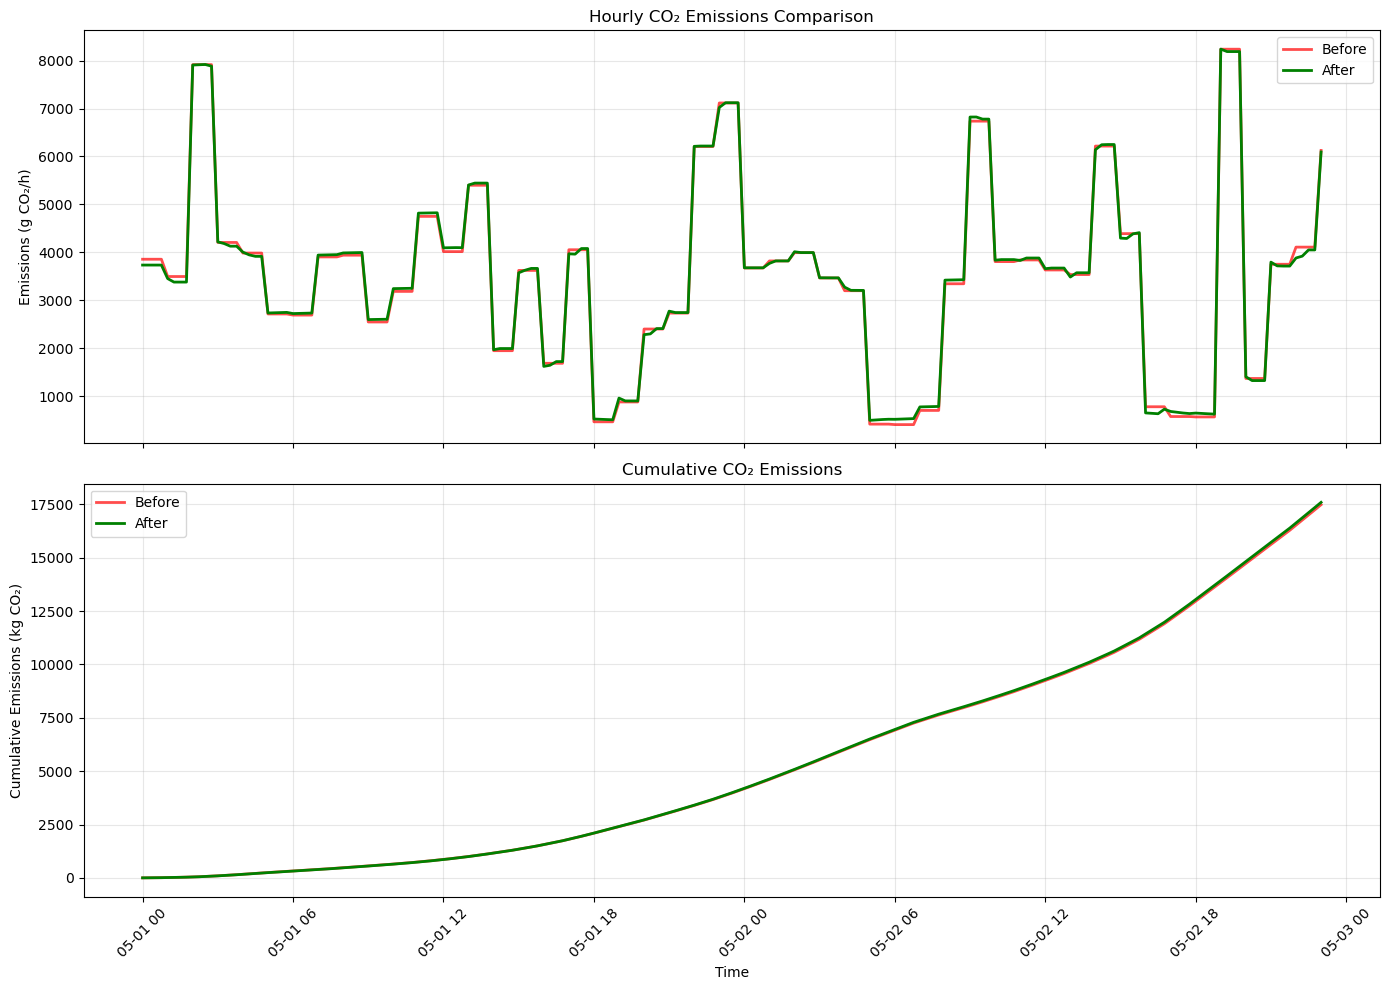

In [24]:
from utils.data_processing import convert_power_to_energy

# Convert power to energy (kWh)
df[f'{SYSTEM_NAME}_Energy Consumption Before (kWh)'] = convert_power_to_energy(
    df[f'{SYSTEM_NAME}_Grid Power Before']
)
df[f'{SYSTEM_NAME}_Energy Consumption After (kWh)'] = convert_power_to_energy(
    df[f'{SYSTEM_NAME}_Grid Power After']
)

# Calculate emissions (g CO₂)
# Emissions = Energy (kWh) × Emission Factor (g CO₂/kWh)
df[f'{SYSTEM_NAME}_Emissions Before (g CO2)'] = (
    df[f'{SYSTEM_NAME}_Energy Consumption Before (kWh)'] * df['Emission Factor (g CO2/kWh)']
)
df[f'{SYSTEM_NAME}_Emissions After (g CO2)'] = (
    df[f'{SYSTEM_NAME}_Energy Consumption After (kWh)'] * df['Emission Factor (g CO2/kWh)']
)

# Calculate hourly emissions for visualization
df[f'{SYSTEM_NAME}_Emissions Before (g CO2/h)'] = (
    df[f'{SYSTEM_NAME}_Grid Power Before'] * df['Emission Factor (g CO2/kWh)']
)
df[f'{SYSTEM_NAME}_Emissions After (g CO2/h)'] = (
    df[f'{SYSTEM_NAME}_Grid Power After'] * df['Emission Factor (g CO2/kWh)']
)

# Calculate total emissions
total_emissions_before = df[f'{SYSTEM_NAME}_Emissions Before (g CO2)'].sum() / 1000  # Convert to kg
total_emissions_after = df[f'{SYSTEM_NAME}_Emissions After (g CO2)'].sum() / 1000  # Convert to kg
emission_savings = total_emissions_before - total_emissions_after
emission_savings_percent = (emission_savings / total_emissions_before * 100) if total_emissions_before > 0 else 0

print(f"\nEmission Analysis:")
print(f"  Total emissions before: {total_emissions_before:.2f} kg CO₂")
print(f"  Total emissions after: {total_emissions_after:.2f} kg CO₂")
print(f"  Emission savings: {emission_savings:.2f} kg CO₂ ({emission_savings_percent:.1f}%)")

# Visualize emissions
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Hourly emissions
axes[0].plot(df.index, df[f'{SYSTEM_NAME}_Emissions Before (g CO2/h)'], 
             label='Before', linewidth=2, alpha=0.7, color='red')
axes[0].plot(df.index, df[f'{SYSTEM_NAME}_Emissions After (g CO2/h)'], 
             label='After', linewidth=2, color='green')
axes[0].set_ylabel('Emissions (g CO₂/h)')
axes[0].set_title('Hourly CO₂ Emissions Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative emissions
cumulative_before = df[f'{SYSTEM_NAME}_Emissions Before (g CO2)'].cumsum() / 1000  # kg
cumulative_after = df[f'{SYSTEM_NAME}_Emissions After (g CO2)'].cumsum() / 1000  # kg
axes[1].plot(df.index, cumulative_before, label='Before', linewidth=2, alpha=0.7, color='red')
axes[1].plot(df.index, cumulative_after, label='After', linewidth=2, color='green')
axes[1].set_ylabel('Cumulative Emissions (kg CO₂)')
axes[1].set_xlabel('Time')
axes[1].set_title('Cumulative CO₂ Emissions')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Step 9: Validate Temperature Schedule

**What this step does:** Validates that the temperature schedule:
1. Stays within allowed temperature bounds (min/max)
2. Respects ramp rate constraints (max temperature change per time step)

**What you'll see:** Validation results showing whether all temperatures are within bounds, min/max values in the schedule, and ramp rate compliance (number of violations if any).


In [25]:
# Simulate temperature based on cooling power
# This is a simplified validation - in practice, you would compare with measured temperatures
df[f'{SYSTEM_NAME}_Simulated Temperature'] = df[f'{SYSTEM_NAME}_Temperature Schedule']

# Check if schedule stays within bounds
within_bounds = (
    (df[f'{SYSTEM_NAME}_Temperature Schedule'] >= MIN_TEMP_ALLOWED) &
    (df[f'{SYSTEM_NAME}_Temperature Schedule'] <= MAX_TEMP_ALLOWED)
).all()

print(f"\nTemperature Schedule Validation:")
print(f"  All temperatures within bounds: {within_bounds}")
print(f"  Min in schedule: {df[f'{SYSTEM_NAME}_Temperature Schedule'].min():.2f} °C (allowed: {MIN_TEMP_ALLOWED} °C)")
print(f"  Max in schedule: {df[f'{SYSTEM_NAME}_Temperature Schedule'].max():.2f} °C (allowed: {MAX_TEMP_ALLOWED} °C)")

# Check ramp rate compliance
temp_changes = df[f'{SYSTEM_NAME}_Temperature Schedule'].diff().abs()
time_step_hours = 0.25  # 15 minutes
max_allowed_change = abs(COOLING_RAMP_SLOPE_IN_K_PER_H) * time_step_hours
ramp_violations = (temp_changes > max_allowed_change).sum()

print(f"\nRamp Rate Validation:")
print(f"  Max allowed change per 15min: {max_allowed_change:.3f} °C")
print(f"  Max actual change: {temp_changes.max():.3f} °C")
print(f"  Ramp violations: {ramp_violations}")



Temperature Schedule Validation:
  All temperatures within bounds: True
  Min in schedule: -24.79 °C (allowed: -25.0 °C)
  Max in schedule: -15.00 °C (allowed: -15.0 °C)

Ramp Rate Validation:
  Max allowed change per 15min: 0.250 °C
  Max actual change: 0.500 °C
  Ramp violations: 24


## Step 10: Generate Reports

**What this step does:** Exports results to Excel files:
- `results.xlsx`: Complete time series data with all calculated columns
- `summary.xlsx`: Summary statistics including total energy, emissions, and savings

**What you'll see:** File paths where reports were saved and a summary table showing key metrics (energy consumption, emissions, savings).


In [26]:
# Prepare DataFrame for export
system_df = df[[
    'Standortverbrauch',
    'Emission Factor (g CO2/kWh)',
    f'{SYSTEM_NAME}_Temperature Schedule',
    f'{SYSTEM_NAME}_Cooling Power After Optimization',
    f'{SYSTEM_NAME}_Grid Power Before',
    f'{SYSTEM_NAME}_Grid Power After',
    f'{SYSTEM_NAME}_Energy Consumption Before (kWh)',
    f'{SYSTEM_NAME}_Energy Consumption After (kWh)',
    f'{SYSTEM_NAME}_Emissions Before (g CO2/h)',
    f'{SYSTEM_NAME}_Emissions After (g CO2/h)',
    f'{SYSTEM_NAME}_Simulated Temperature',
]].copy()

# Rename columns (remove system name prefix)
rename_dict = {
    f'{SYSTEM_NAME}_Temperature Schedule': 'Temperature Schedule',
    f'{SYSTEM_NAME}_Cooling Power After Optimization': 'Cooling Power After Optimization',
    f'{SYSTEM_NAME}_Grid Power Before': 'Grid Power Before',
    f'{SYSTEM_NAME}_Grid Power After': 'Grid Power After',
    f'{SYSTEM_NAME}_Energy Consumption Before (kWh)': 'Energy Consumption Before (kWh)',
    f'{SYSTEM_NAME}_Energy Consumption After (kWh)': 'Energy Consumption After (kWh)',
    f'{SYSTEM_NAME}_Emissions Before (g CO2/h)': 'Emissions Before (g CO2/h)',
    f'{SYSTEM_NAME}_Emissions After (g CO2/h)': 'Emissions After (g CO2/h)',
    f'{SYSTEM_NAME}_Simulated Temperature': 'Simulated Temperature',
}
system_df = system_df.rename(columns=rename_dict)

# Save Excel report
excel_path = os.path.join(report_directory, 'results.xlsx')
system_df.to_excel(excel_path, index=True)
print(f"\nExcel report saved: {excel_path}")

# Create summary report
summary = {
    'Metric': [
        'Total Energy Before (kWh)',
        'Total Energy After (kWh)',
        'Energy Savings (kWh)',
        'Total Emissions Before (kg CO₂)',
        'Total Emissions After (kg CO₂)',
        'Emission Savings (kg CO₂)',
        'Emission Savings (%)',
    ],
    'Value': [
        df[f'{SYSTEM_NAME}_Energy Consumption Before (kWh)'].sum(),
        df[f'{SYSTEM_NAME}_Energy Consumption After (kWh)'].sum(),
        df[f'{SYSTEM_NAME}_Energy Consumption Before (kWh)'].sum() - df[f'{SYSTEM_NAME}_Energy Consumption After (kWh)'].sum(),
        total_emissions_before,
        total_emissions_after,
        emission_savings,
        emission_savings_percent,
    ]
}
summary_df = pd.DataFrame(summary)

summary_path = os.path.join(report_directory, 'summary.xlsx')
summary_df.to_excel(summary_path, index=False)
print(f"Summary report saved: {summary_path}")
print(f"\nSummary:")
print(summary_df.to_string(index=False))



Excel report saved: reports/ecocool/manual_analysis\results.xlsx
Summary report saved: reports/ecocool/manual_analysis\summary.xlsx

Summary:
                         Metric         Value
      Total Energy Before (kWh) 135755.531846
       Total Energy After (kWh) 136629.240052
           Energy Savings (kWh)   -873.708206
Total Emissions Before (kg CO₂)  17486.074238
 Total Emissions After (kg CO₂)  17596.180210
      Emission Savings (kg CO₂)   -110.105971
           Emission Savings (%)     -0.629678


## Summary


In [28]:
print("="*70)
print("MANUAL ANALYSIS COMPLETE")
print("="*70)
print(f"\nResults saved to: {report_directory}")
print(f"\nSystem: {SYSTEM_NAME}")
print(f"\nKey Results:")
print(f"  Emission savings: {emission_savings:.2f} kg CO₂ ({emission_savings_percent:.1f}%)")
print(f"  Energy before: {df[f'{SYSTEM_NAME}_Energy Consumption Before (kWh)'].sum():.2f} kWh")
print(f"  Energy after: {df[f'{SYSTEM_NAME}_Energy Consumption After (kWh)'].sum():.2f} kWh")

if os.path.exists(report_directory):
    files = os.listdir(report_directory)
    print(f"\nGenerated files:")
    for file in files:
        file_path = os.path.join(report_directory, file)
        size = os.path.getsize(file_path) / 1024  # KB
        print(f"  - {file}: {size:.1f} KB")


MANUAL ANALYSIS COMPLETE

Results saved to: reports/ecocool/manual_analysis

System: EcoCool

Key Results:
  Emission savings: -110.11 kg CO₂ (-0.6%)
  Energy before: 135755.53 kWh
  Energy after: 136629.24 kWh

Generated files:
  - results.xlsx: 21.3 KB
  - summary.xlsx: 5.1 KB
